# 01 — Exploratory Data Analysis

**Dataset:** 470 days of real daily revenue from an independent community pharmacy, covering 2019-12-15 to 2021-05-10 (17 months).

**Data notice.** Daily revenue values in this dataset are real observed sales, multiplied by a single constant scaling factor to obscure the exact revenue level for privacy. All statistical properties — day-of-week patterns, trends, structural breaks, variance ratios, regression coefficients (as percentages), test statistics, and p-values — are **identical** to those computed on the raw data. Only absolute currency values are hidden. Reported values are in **LC** (local currency, scaled).

**Purpose of this notebook:** get a first read on the data — coverage, distribution, obvious patterns, missing days — before hypothesis testing in later notebooks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titleweight"] = "bold"

DATA = Path("../data/daily_sales_final.csv")
df = pd.read_csv(DATA, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(470, 2)


,date,revenue_scaled
0,2019-12-15,141552.21
1,2019-12-16,131409.19
2,2019-12-17,118912.16
3,2019-12-18,154326.18
4,2019-12-19,151141.34


## 1. Coverage

In [2]:
min_d, max_d = df["date"].min(), df["date"].max()
expected = pd.date_range(min_d, max_d, freq="D")
missing = sorted(set(expected) - set(df["date"]))

print(f"Date range: {min_d.date()} to {max_d.date()}")
print(f"Expected days: {len(expected)}   Actual days: {len(df)}   Missing: {len(missing)} ({100*len(missing)/len(expected):.1f}%)")

# Cluster missing days into contiguous ranges
if missing:
    ranges = []
    start = prev = missing[0]
    for d in missing[1:]:
        if (d - prev).days == 1:
            prev = d
        else:
            ranges.append((start, prev))
            start = prev = d
    ranges.append((start, prev))
    print(f"\nMissing-day ranges ({len(ranges)}):")
    for s, e in ranges:
        n = (e - s).days + 1
        print(f"  {s.date()} to {e.date()} ({n} day{'s' if n > 1 else ''})")

Date range: 2019-12-15 to 2021-05-10
Expected days: 513   Actual days: 470   Missing: 43 (8.4%)

Missing-day ranges (7):
  2020-02-25 to 2020-03-02 (7 days)
  2020-05-19 to 2020-05-25 (7 days)
  2020-06-23 to 2020-06-29 (7 days)
  2020-09-22 to 2020-09-28 (7 days)
  2020-12-22 to 2020-12-28 (7 days)
  2021-02-02 to 2021-02-08 (7 days)
  2021-04-13 to 2021-04-13 (1 day)


*Missing-day interpretation:* the six 7-day gaps are known export failures — weeks when the daily report did not run. The pharmacy was open on those days. Treated as MCAR (missing completely at random) for hypothesis testing; NOT imputed for descriptive analysis.

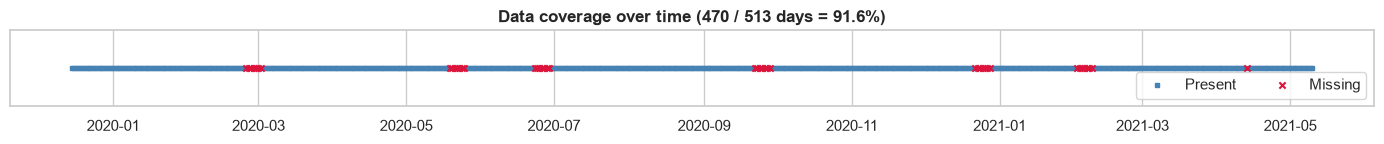

In [3]:
# Visual coverage map — one dot per day, colored by present/absent
cov = pd.DataFrame({"date": expected})
cov["present"] = cov["date"].isin(df["date"])

fig, ax = plt.subplots(figsize=(14, 1.6))
ax.scatter(cov[cov["present"]]["date"], [1]*cov["present"].sum(), s=6, c="steelblue", marker="s", label="Present")
ax.scatter(cov[~cov["present"]]["date"], [1]*(~cov["present"]).sum(), s=20, c="crimson", marker="x", label="Missing")
ax.set_yticks([])
ax.set_title("Data coverage over time (470 / 513 days = 91.6%)")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.savefig("../charts/01_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Distribution & summary statistics

In [4]:
summary = df["revenue_scaled"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print(summary.round(0))

count       470.0
mean     120000.0
std       26072.0
min       37733.0
5%        80102.0
25%      102720.0
50%      119154.0
75%      138021.0
95%      160080.0
max      284489.0
Name: revenue_scaled, dtype: float64


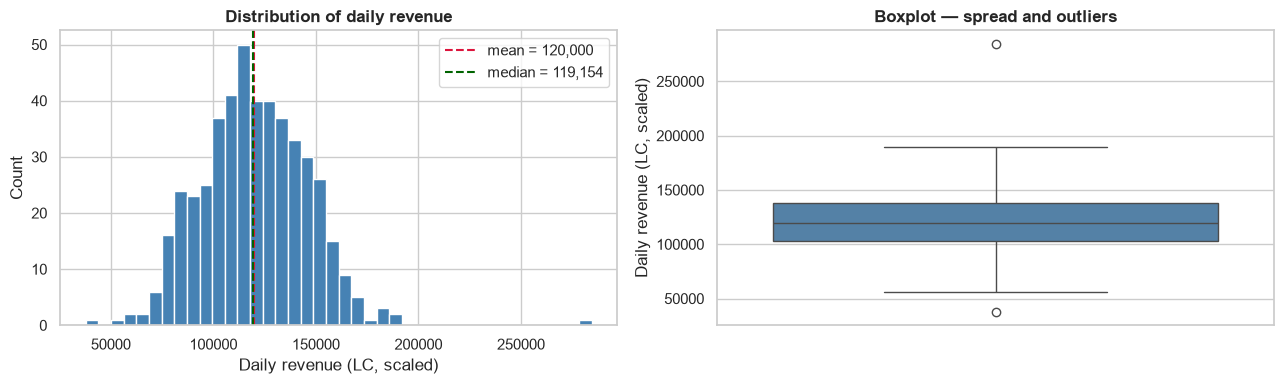

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["revenue_scaled"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(df["revenue_scaled"].mean(), color="crimson", linestyle="--", label=f"mean = {df['revenue_scaled'].mean():,.0f}")
axes[0].axvline(df["revenue_scaled"].median(), color="darkgreen", linestyle="--", label=f"median = {df['revenue_scaled'].median():,.0f}")
axes[0].set_xlabel("Daily revenue (LC, scaled)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of daily revenue")
axes[0].legend()

sns.boxplot(y=df["revenue_scaled"], ax=axes[1], color="steelblue")
axes[1].set_ylabel("Daily revenue (LC, scaled)")
axes[1].set_title("Boxplot — spread and outliers")

plt.tight_layout()
plt.savefig("../charts/02_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** distribution is roughly symmetric around ~120K with a long right tail. Skewness and kurtosis:

In [6]:
from scipy.stats import skew, kurtosis
print(f"Skewness: {skew(df['revenue_scaled']):.3f}")
print(f"Excess kurtosis: {kurtosis(df['revenue_scaled']):.3f}")

Skewness: 0.500
Excess kurtosis: 2.692


## 3. Full time series + rolling means

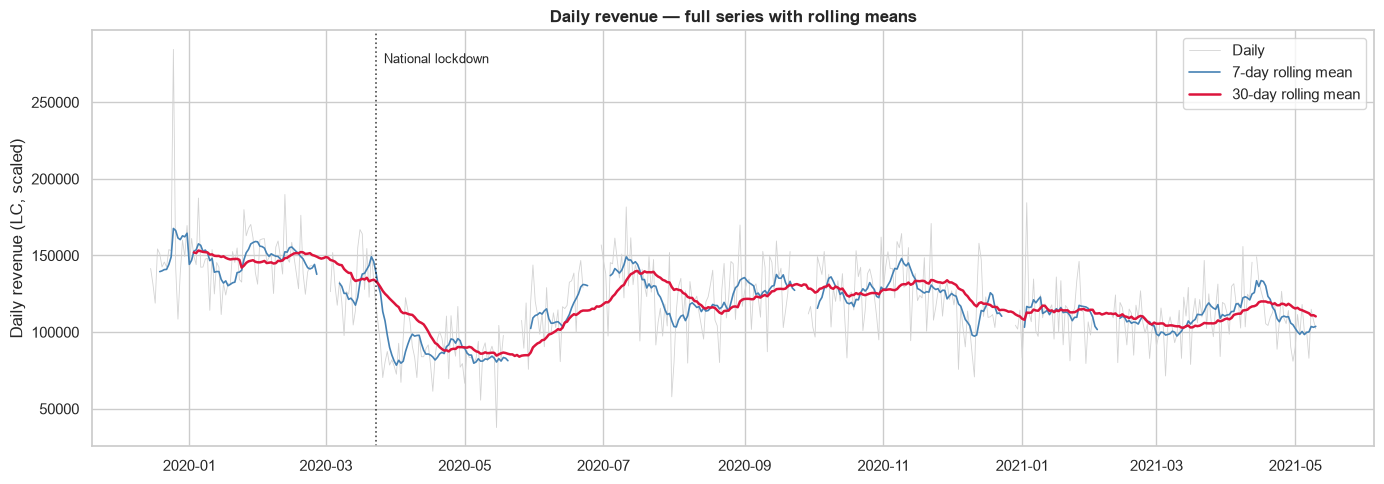

In [7]:
df = df.set_index("date").asfreq("D")  # explicit daily frequency (NaN on missing days)
df["r7"] = df["revenue_scaled"].rolling(7, min_periods=5).mean()
df["r30"] = df["revenue_scaled"].rolling(30, min_periods=20).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["revenue_scaled"], color="lightgrey", linewidth=0.6, label="Daily")
ax.plot(df.index, df["r7"], color="steelblue", linewidth=1.2, label="7-day rolling mean")
ax.plot(df.index, df["r30"], color="crimson", linewidth=1.8, label="30-day rolling mean")

# Reference marker: 23 Mar 2020 (nationwide lockdown announced)
ax.axvline(pd.Timestamp("2020-03-23"), color="black", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(pd.Timestamp("2020-03-23"), ax.get_ylim()[1]*0.95, "  National lockdown", fontsize=9, va="top")

ax.set_ylabel("Daily revenue (LC, scaled)")
ax.set_title("Daily revenue — full series with rolling means")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../charts/03_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** the 30-day rolling mean clearly shows a step-down starting late March 2020 with slow partial recovery through mid-2020, and continued elevation-then-fall through 2020-2021. This visual motivates the structural-break analysis in notebook 02.

## 4. Monthly aggregates

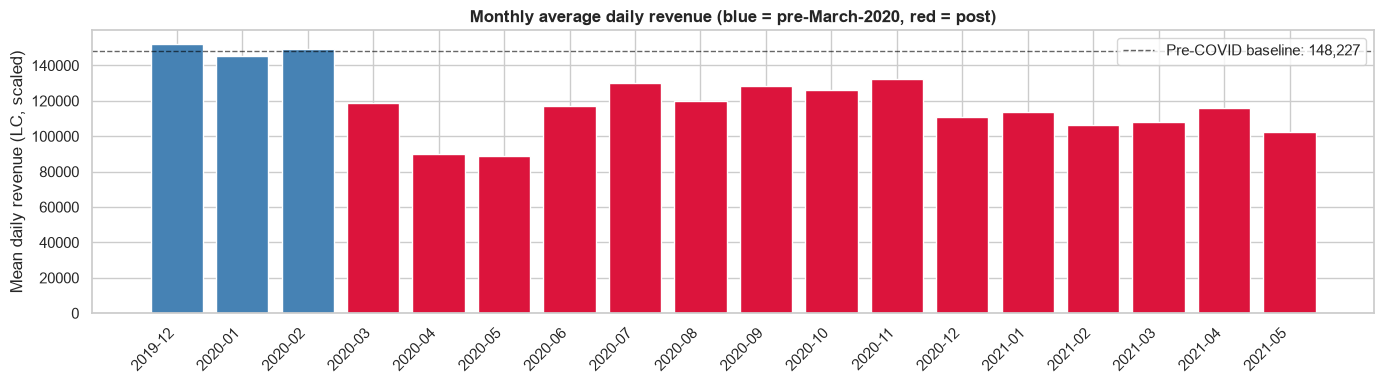

In [8]:
monthly = df["revenue_scaled"].resample("ME").mean().dropna()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["steelblue" if d < pd.Timestamp("2020-03-01") else "crimson" for d in monthly.index]
ax.bar(monthly.index.strftime("%Y-%m"), monthly.values, color=colors, edgecolor="white")

# Baseline reference: mean of Dec 2019 - Feb 2020
baseline = df.loc["2019-12":"2020-02", "revenue_scaled"].mean()
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Pre-COVID baseline: {baseline:,.0f}")

ax.set_ylabel("Mean daily revenue (LC, scaled)")
ax.set_title("Monthly average daily revenue (blue = pre-March-2020, red = post)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../charts/04_monthly.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Day-of-week pattern

In [9]:

# BD1..BD5 for business days; WE1 and WE2 for weekend days.
DOW_MAP = {6: "BD1", 0: "BD2", 1: "BD3", 2: "BD4", 3: "BD5", 4: "WE1", 5: "WE2"}
LABEL_ORDER = ["BD1", "BD2", "BD3", "BD4", "BD5", "WE1", "WE2"]

work = df.dropna(subset=["revenue_scaled"]).copy()
work["dow_neutral"] = work.index.dayofweek.map(DOW_MAP)

dow_stats = work.groupby("dow_neutral")["revenue_scaled"].agg(["mean", "std", "count"]).reindex(LABEL_ORDER)
print(dow_stats.round(0))

                 mean      std  count
dow_neutral                          
BD1          126824.0  24529.0     68
BD2          123164.0  23437.0     68
BD3          122385.0  22563.0     66
BD4          123843.0  30794.0     67
BD5          122901.0  22355.0     67
WE1           95589.0  22511.0     67
WE2          125181.0  22045.0     67


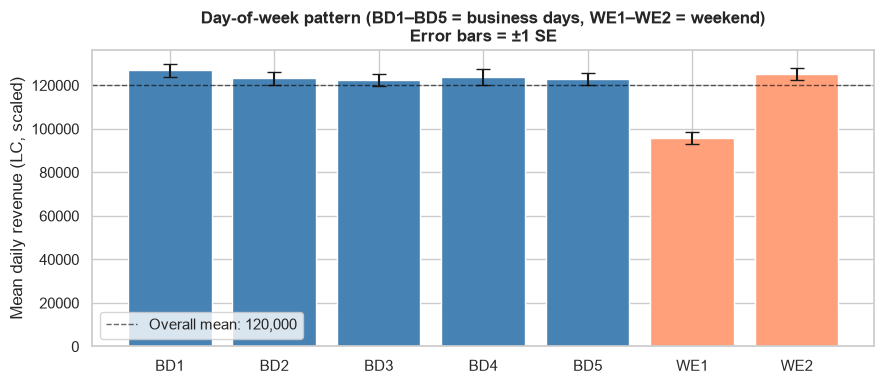


BD1 vs overall mean: +5.7%
WE1 vs overall mean: -20.3%
WE2 vs overall mean: +4.3%


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
overall = work["revenue_scaled"].mean()
colors = ["steelblue"]*5 + ["lightsalmon"]*2
ax.bar(dow_stats.index, dow_stats["mean"], yerr=dow_stats["std"]/np.sqrt(dow_stats["count"]),
       capsize=5, color=colors, edgecolor="white")
ax.axhline(overall, color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Overall mean: {overall:,.0f}")
ax.set_ylabel("Mean daily revenue (LC, scaled)")
ax.set_title("Day-of-week pattern (BD1–BD5 = business days, WE1–WE2 = weekend)\nError bars = ±1 SE")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/05_dow.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nBD1 vs overall mean: {(dow_stats.loc['BD1', 'mean']/overall - 1)*100:+.1f}%")
print(f"WE1 vs overall mean: {(dow_stats.loc['WE1', 'mean']/overall - 1)*100:+.1f}%")
print(f"WE2 vs overall mean: {(dow_stats.loc['WE2', 'mean']/overall - 1)*100:+.1f}%")

**Observation:** a clear BD1 spike is visible — motivates H4a (first-business-day effect). Formal ANOVA + robust regression is in notebook 04.

## 6. Month-phase quick look (H4b setup)

                     mean      std  count
month_phase                              
start (day 1-5)  119236.0  27051.0     79
middle           121389.0  25570.0    320
end (last 5)     114591.0  26835.0     71


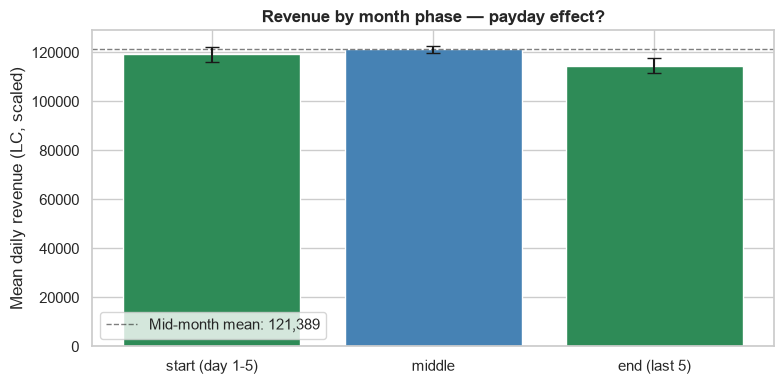


Start-of-month vs mid: -1.8%
End-of-month vs mid:   -5.6%


In [11]:
def month_phase(d):
    days_in_month = d.days_in_month
    if d.day <= 5:
        return "start (day 1-5)"
    elif d.day > days_in_month - 5:
        return "end (last 5)"
    else:
        return "middle"

work["month_phase"] = work.index.map(month_phase)
phase_stats = work.groupby("month_phase")["revenue_scaled"].agg(["mean", "std", "count"])
phase_stats = phase_stats.reindex(["start (day 1-5)", "middle", "end (last 5)"])
print(phase_stats.round(0))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(phase_stats.index, phase_stats["mean"],
       yerr=phase_stats["std"]/np.sqrt(phase_stats["count"]), capsize=5,
       color=["seagreen", "steelblue", "seagreen"], edgecolor="white")
mid_mean = phase_stats.loc["middle", "mean"]
ax.axhline(mid_mean, color="black", linestyle="--", linewidth=1, alpha=0.5, label=f"Mid-month mean: {mid_mean:,.0f}")
ax.set_ylabel("Mean daily revenue (LC, scaled)")
ax.set_title("Revenue by month phase — payday effect?")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/06_month_phase.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nStart-of-month vs mid: {(phase_stats.loc['start (day 1-5)', 'mean']/mid_mean - 1)*100:+.1f}%")
print(f"End-of-month vs mid:   {(phase_stats.loc['end (last 5)', 'mean']/mid_mean - 1)*100:+.1f}%")

**Observation:** if start-of-month and end-of-month means visibly exceed mid-month, H4b (payday-cycle effect) is worth formal testing in notebook 04.

## 7. Handoff to hypothesis notebooks

Visual takeaways from this EDA that will drive the formal tests:

1. **Level break around Mar-Apr 2020** — obvious in the 30-day rolling mean. Chow test + PELT change-point detection in `02_change_points.ipynb`.
2. **Persistent regime** — 2021 monthly means look different from pre-COVID levels. H2 also handled in notebook 02.
3. **Apparent wider spread in 2020 onward** — visible on the raw series and boxplot. Variance regime break tested (and revisited under regime decomposition) in `03_volatility.ipynb`.
4. **Weekend depression** — visible in the day-of-week chart. Tested with HAC-robust regression in `04_calendar_effects.ipynb`.
5. **Payday-cycle effect** (textbook prior, not visually evident in EDA) — tested in the same notebook against a competing institutional-mechanism prior.
